In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [2]:
plt.style.use("ggplot")

In [3]:
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception as e:
    print("한글 폰트 설정을 건너뜁니다:", e)

In [4]:
df = pd.read_csv("jeju_bus.csv")

df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38


In [5]:
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


In [6]:
df.shape

(210457, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210457 entries, 0 to 210456
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                210457 non-null  int64  
 1   date              210457 non-null  str    
 2   route_id          210457 non-null  int64  
 3   vh_id             210457 non-null  int64  
 4   route_nm          210457 non-null  str    
 5   now_latitude      210457 non-null  float64
 6   now_longitude     210457 non-null  float64
 7   now_station       210457 non-null  str    
 8   now_arrive_time   210457 non-null  str    
 9   distance          210457 non-null  float64
 10  next_station      210457 non-null  str    
 11  next_latitude     210457 non-null  float64
 12  next_longitude    210457 non-null  float64
 13  next_arrive_time  210457 non-null  int64  
dtypes: float64(5), int64(4), str(5)
memory usage: 22.5 MB


In [8]:
df.describe()

,id,route_id,vh_id,now_latitude,now_longitude,distance,next_latitude,next_longitude,next_arrive_time
count,210457.000000,2.104570e+05,2.104570e+05,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000
mean,105228.000000,4.052491e+08,7.988694e+06,33.434528,126.603451,490.256100,33.434711,126.603687,85.380824
std,60753.847139,9.132404e+04,6.774077e+03,0.102350,0.123961,520.563932,0.102224,0.123838,85.051170
min,0.000000,4.051360e+08,7.983000e+06,33.244382,126.473300,97.000000,33.244382,126.473300,6.000000
25%,52614.000000,4.051365e+08,7.983093e+06,33.325283,126.523900,291.000000,33.325283,126.524550,44.000000
50%,105228.000000,4.053201e+08,7.983431e+06,33.484667,126.551050,384.000000,33.484860,126.551050,66.000000
75%,157842.000000,4.053201e+08,7.997041e+06,33.500197,126.650322,542.000000,33.500228,126.650322,102.000000
max,210456.000000,4.053281e+08,7.997124e+06,33.556167,126.935188,7461.000000,33.556167,126.935188,2996.000000


In [9]:
missing_count = df.isnull().sum()
missing_ratio = df.isnull().mean()

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio": missing_ratio
})

missing_df

,missing_count,missing_ratio
id,0,0.0
date,0,0.0
route_id,0,0.0
vh_id,0,0.0
route_nm,0,0.0
now_latitude,0,0.0
now_longitude,0,0.0
now_station,0,0.0
now_arrive_time,0,0.0
distance,0,0.0


In [10]:
df["now_hour"] = df["now_arrive_time"].str.replace("시", "", regex=False).astype(int)

In [11]:
df[["now_arrive_time", "now_hour"]].head()

,now_arrive_time,now_hour
0,06시,6
1,06시,6
2,06시,6
3,06시,6
4,07시,7


In [12]:
df["date"] = pd.to_datetime(df["date"])

In [13]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek

In [14]:
df[["date", "year", "month", "day", "dayofweek"]].head()

,date,year,month,day,dayofweek
0,2019-10-15,2019,10,15,1
1,2019-10-15,2019,10,15,1
2,2019-10-15,2019,10,15,1
3,2019-10-15,2019,10,15,1
4,2019-10-15,2019,10,15,1


In [15]:
df["next_arrive_time"].describe()

count    210457.000000
mean         85.380824
std          85.051170
min           6.000000
25%          44.000000
50%          66.000000
75%         102.000000
max        2996.000000
Name: next_arrive_time, dtype: float64

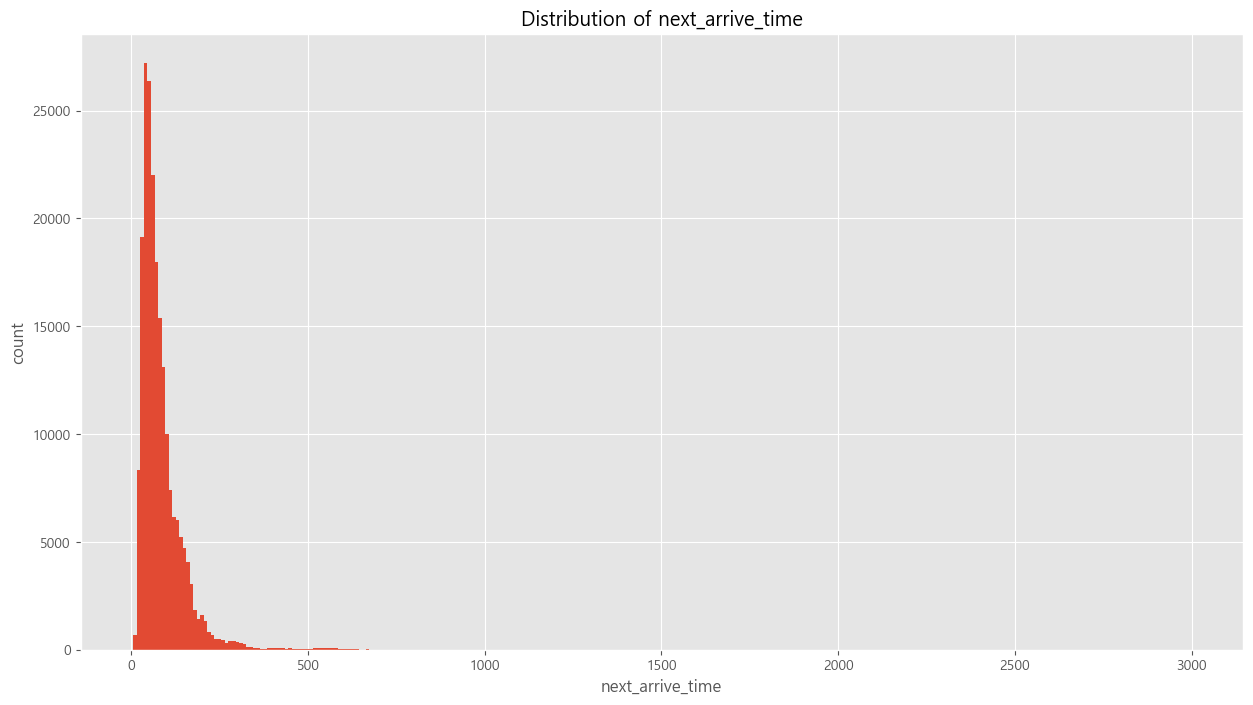

In [16]:
plt.figure(figsize=(15, 8))
plt.hist(df["next_arrive_time"], bins=300)
plt.title("Distribution of next_arrive_time")
plt.xlabel("next_arrive_time")
plt.ylabel("count")
plt.show()

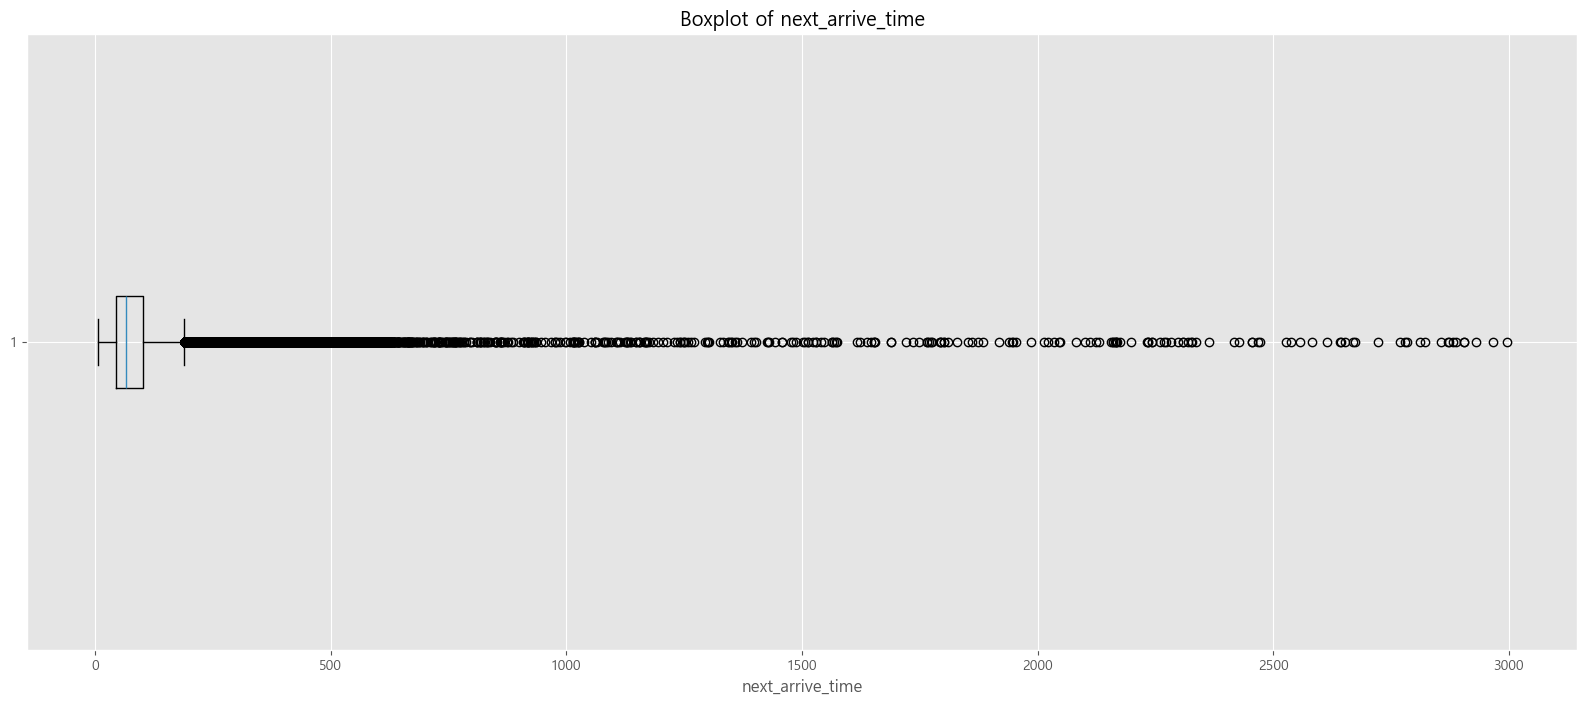

In [17]:
plt.figure(figsize=(20, 8))
plt.boxplot(df["next_arrive_time"], vert=False)
plt.title("Boxplot of next_arrive_time")
plt.xlabel("next_arrive_time")
plt.show()

In [18]:
time_quantile = df["next_arrive_time"].quantile([0.90, 0.95, 0.99])
time_quantile

0.90    154.0
0.95    194.0
0.99    340.0
Name: next_arrive_time, dtype: float64

In [19]:
over_300_count = (df["next_arrive_time"] > 300).sum()
over_600_count = (df["next_arrive_time"] > 600).sum()
over_1000_count = (df["next_arrive_time"] > 1000).sum()

print("300 초과:", over_300_count)
print("600 초과:", over_600_count)
print("1000 초과:", over_1000_count)

300 초과: 3070
600 초과: 438
1000 초과: 200


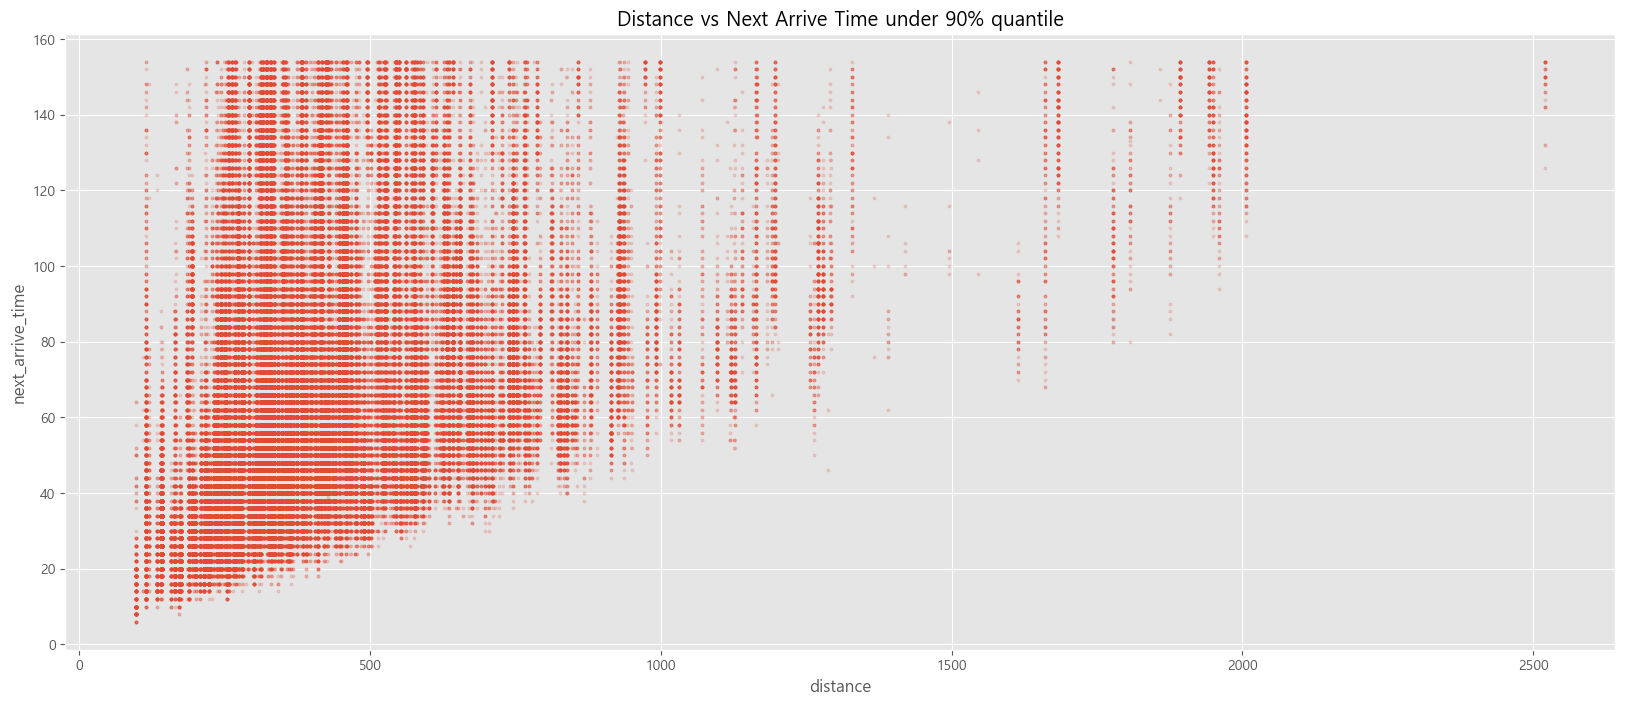

In [20]:
q90 = df["next_arrive_time"].quantile(0.90)

df_under_q90 = df[df["next_arrive_time"] <= q90]

plt.figure(figsize=(20, 8))
plt.scatter(
    df_under_q90["distance"],
    df_under_q90["next_arrive_time"],
    alpha=0.2,
    s=5
)
plt.title("Distance vs Next Arrive Time under 90% quantile")
plt.xlabel("distance")
plt.ylabel("next_arrive_time")
plt.show()

In [47]:
(df["next_arrive_time"] > 300).sum()

np.int64(3070)

In [48]:
df[["distance", "next_arrive_time", "now_hour"]]

,distance,next_arrive_time,now_hour
0,266.0,24,6
1,333.0,36,6
2,415.0,40,6
3,578.0,42,6
4,374.0,64,7
...,...,...,...
210452,528.0,96,21
210453,280.0,50,21
210454,114.0,16,21
210455,223.0,38,21


In [52]:
corr_df = pd.DataFrame({
    "kor": [90, 88, 70, 100, 95],
    "eng": [85, 90, 65, 98, 90],
    "gym": [98, 87, 72, 80, 78],
 "height": [1.8, 1.6, 1.7, 1.45, 1.72],
 "weight": [90, 80, 100, 85, 90]
})
corr_df

,kor,eng,gym,height
0,90,85,98,1.80
1,88,90,87,1.60
2,70,65,72,1.70
3,100,98,80,1.45
4,95,90,78,1.72


In [54]:
# 상관계수 뽑기
corr_df.corr()

,kor,eng,gym,height
kor,1.000000,0.970175,0.346246,-0.411575
eng,0.970175,1.000000,0.356002,-0.525669
gym,0.346246,0.356002,1.000000,0.327010
height,-0.411575,-0.525669,0.327010,1.000000


In [56]:
df[["now_hour", "next_arrive_time"]]

,now_hour,next_arrive_time
0,6,24
1,6,36
2,6,40
3,6,42
4,7,64
...,...,...
210452,21,96
210453,21,50
210454,21,16
210455,21,38


In [59]:
df[df["now_hour"] == 5].sort_values(by="next_arrive_time")

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,now_hour,year,month,day,dayofweek,station_segment
70108,70108,2019-10-19,405320114,7983228,201-14,33.466033,126.934898,성산리 취락구조,05시,134.0,성산리,33.465214,126.935188,14,5,2019,10,19,5,성산리 취락구조 -> 성산리
84598,84598,2019-10-20,405320114,7983228,201-14,33.466033,126.934898,성산리 취락구조,05시,134.0,성산리,33.465214,126.935188,16,5,2019,10,20,6,성산리 취락구조 -> 성산리
125371,125371,2019-10-23,405136012,7997033,360-12,33.500033,126.504650,오라오거리,05시,157.0,명신마을,33.499623,126.503028,16,5,2019,10,23,2,오라오거리 -> 명신마을
190526,190526,2019-10-27,405320116,7983065,201-16,33.249091,126.509224,서귀포버스터미널(가상정류소),05시,189.0,대륜동주민센터,33.248487,126.511195,16,5,2019,10,27,6,서귀포버스터미널(가상정류소) -> 대륜동주민센터
26541,26541,2019-10-16,405320118,7983201,201-18,33.466033,126.934898,성산리 취락구조,05시,134.0,성산리,33.465214,126.935188,18,5,2019,10,16,2,성산리 취락구조 -> 성산리
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78568,78568,2019-10-20,405136002,7997082,360-2,33.477560,126.477406,탐라도서관,05시,518.0,제주고등학교/중흥S클래스,33.476260,126.481417,1946,5,2019,10,20,6,탐라도서관 -> 제주고등학교/중흥S클래스
66462,66462,2019-10-19,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,05시,347.0,정존마을,33.481317,126.473300,2048,5,2019,10,19,5,노형초등학교 -> 정존마을
127314,127314,2019-10-23,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,05시,347.0,정존마을,33.481317,126.473300,2176,5,2019,10,23,2,노형초등학교 -> 정존마을
157456,157456,2019-10-25,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,05시,347.0,정존마을,33.481317,126.473300,2456,5,2019,10,25,4,노형초등학교 -> 정존마을


In [22]:
corr_cols = [
    "distance",
    "next_arrive_time",
    "now_hour"
]

corr_data = df[corr_cols]
corr_matrix = corr_data.corr()
corr_matrix

,distance,next_arrive_time,now_hour
distance,1.000000,0.437166,-0.004834
next_arrive_time,0.437166,1.000000,-0.001209
now_hour,-0.004834,-0.001209,1.000000


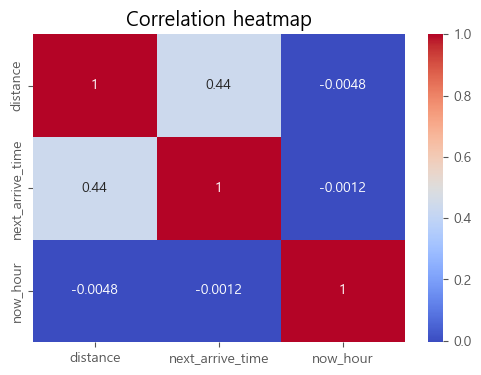

In [23]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [24]:
hour_count = df.groupby("now_hour")["next_arrive_time"].count()
hour_count

now_hour
0         5
5       487
6      8409
7     13581
8     13838
9     13700
10    13011
11    12524
12    13433
13    13197
14    12592
15    12846
16    13476
17    13090
18    12987
19    13275
20    11852
21    11230
22     6470
23      454
Name: next_arrive_time, dtype: int64

In [25]:
hour_mean_time = df.groupby("now_hour")["next_arrive_time"].mean()
hour_mean_time

now_hour
0      56.000000
5     132.956879
6      85.986443
7      85.488697
8      87.666715
9      82.414015
10     82.623780
11     83.547988
12     83.550733
13     84.070471
14     84.036134
15     84.904250
16     86.759573
17     90.705271
18     94.958882
19     87.240979
20     83.124705
21     82.479252
22     75.355796
23     63.387665
Name: next_arrive_time, dtype: float64

In [26]:
hour_summary = df.groupby("now_hour")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)
hour_summary

,count,mean,median
now_hour,,,
0,5,56.000000,36.0
5,487,132.956879,66.0
6,8409,85.986443,64.0
7,13581,85.488697,66.0
8,13838,87.666715,66.0
9,13700,82.414015,64.0
10,13011,82.623780,66.0
11,12524,83.547988,66.0
12,13433,83.550733,66.0


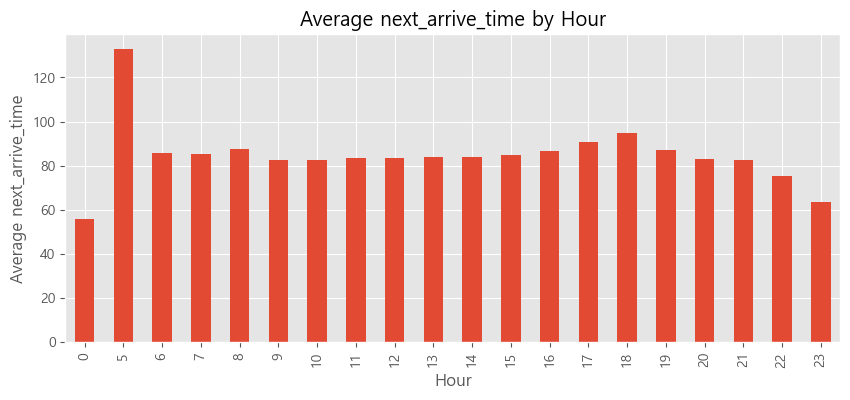

In [27]:
hour_summary["mean"].plot(kind="bar", figsize=(10, 4))
plt.title("Average next_arrive_time by Hour")
plt.xlabel("Hour")
plt.ylabel("Average next_arrive_time")
plt.show()

In [28]:
day_count = df.groupby("dayofweek")["next_arrive_time"].count()
day_count

dayofweek
0    30353
1    31311
2    30818
3    30968
4    30003
5    28806
6    28198
Name: next_arrive_time, dtype: int64

In [29]:
day_mean_time = df.groupby("dayofweek")["next_arrive_time"].mean()
day_mean_time

dayofweek
0    85.926136
1    85.476095
2    86.133721
3    86.487632
4    86.913709
5    83.720544
6    82.714732
Name: next_arrive_time, dtype: float64

In [30]:
hour_summary = df.groupby("dayofweek")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)
hour_summary

,count,mean,median
dayofweek,,,
0,30353,85.926136,66.0
1,31311,85.476095,66.0
2,30818,86.133721,66.0
3,30968,86.487632,66.0
4,30003,86.913709,66.0
5,28806,83.720544,64.0
6,28198,82.714732,64.0


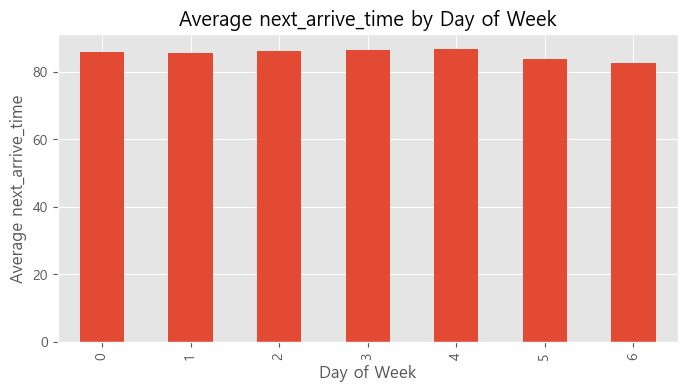

In [31]:
hour_summary["mean"].plot(kind="bar", figsize=(8, 4))
plt.title("Average next_arrive_time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average next_arrive_time")
plt.show()

In [32]:
route_count = df.groupby("route_nm")["next_arrive_time"].count()
route_count

route_nm
201-11     7895
201-12    11871
201-13     2631
201-14    12999
201-15     2289
201-16    15451
201-17     5102
201-18     2558
201-21     2670
201-22     7723
201-24     2368
201-26     2665
201-27     5950
281-1     19150
281-2     25884
360-1     21668
360-12     8037
360-2      7709
360-7      2070
365-21    11826
365-22    31941
Name: next_arrive_time, dtype: int64

In [33]:
route_mean_time = df.groupby("route_nm")["next_arrive_time"].mean()
route_mean_time

route_nm
201-11     68.901710
201-12     67.602392
201-13     68.403649
201-14     66.634818
201-15     71.313237
201-16     68.122969
201-17     69.239122
201-18     67.643471
201-21     65.985019
201-22     63.955199
201-24     66.205659
201-26     66.512570
201-27     70.824370
281-1      87.579634
281-2      85.744862
360-1      92.063688
360-12    111.322633
360-2     108.270852
360-7      94.172947
365-21    114.673939
365-22    101.339188
Name: next_arrive_time, dtype: float64

In [34]:
route_summary = df.groupby("route_nm")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)
route_summary = route_summary.sort_values("mean", ascending=False)
route_summary

,count,mean,median
route_nm,,,
365-21,11826,114.673939,90.0
360-12,8037,111.322633,82.0
360-2,7709,108.270852,84.0
365-22,31941,101.339188,80.0
360-7,2070,94.172947,82.0
360-1,21668,92.063688,80.0
281-1,19150,87.579634,68.0
281-2,25884,85.744862,70.0
201-15,2289,71.313237,54.0


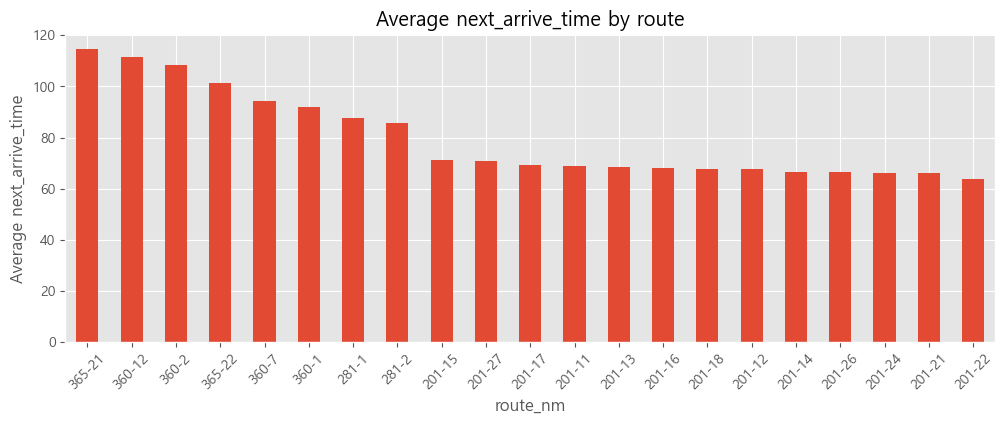

In [35]:
route_summary["mean"].plot(kind="bar", figsize=(12, 4))
plt.title("Average next_arrive_time by route")
plt.xlabel("route_nm")
plt.ylabel("Average next_arrive_time")
plt.xticks(rotation=45)
plt.show()

In [36]:
df["station_segment"] = (
    df["now_station"].astype(str)
    + " -> "
    + df["next_station"].astype(str)
)

In [37]:
df[["now_station", "next_station", "station_segment"]].head()

,now_station,next_station,station_segment
0,제주대학교입구,제대마을,제주대학교입구 -> 제대마을
1,제대마을,제대아파트,제대마을 -> 제대아파트
2,제대아파트,제주대학교,제대아파트 -> 제주대학교
3,남국원(아라방면),제주여자중고등학교(아라방면),남국원(아라방면) -> 제주여자중고등학교(아라방면)
4,도호동,은남동,도호동 -> 은남동


In [38]:
segment_count = df.groupby("station_segment")["next_arrive_time"].count()
segment_count.sort_values(ascending=False).head(10)

station_segment
은남동 -> 도호동                             1933
남국원(아라방면) -> 아라초등학교                    1915
아라초등학교 -> 아라주공아파트                      1911
제원아파트 -> 은남동                           1897
아라주공아파트 -> 인다마을                        1849
제주여자중고등학교(아라방면) -> 남국원(아라방면)           1794
인다마을 -> 제주대학교병원                        1779
제주중앙여자고등학교(아라방면) -> 제주여자중고등학교(아라방면)    1761
제주시청(아라방면) -> 고산동산(아라방면)               1760
제주지방법원(아라방면) -> 제주중앙여자고등학교(아라방면)       1741
Name: next_arrive_time, dtype: int64

In [39]:
segment_mean_time = df.groupby("station_segment")["next_arrive_time"].mean()
segment_mean_time.sort_values(ascending=False).head(10)

station_segment
노형초등학교 -> 정존마을              2182.800000
부영아파트 -> 제주고등학교/중흥S클래스      2166.000000
서귀포여자고등학교 -> 수모루            2160.000000
노형오거리 -> 노형초등학교             1773.777778
사회복지법인 춘강 -> 산천단 한국폴리텍대학    1478.000000
정존마을 -> 제주한라대학교             1253.000000
한국병원 -> 제주버스터미널(가상정류소)      1125.333333
제주고등학교/중흥S클래스 -> 탐라도서관       634.500000
탐라도서관 -> 제주고등학교/중흥S클래스       613.400000
성판악 -> 수악교                   562.773234
Name: next_arrive_time, dtype: float64

In [40]:
segment_summary = df.groupby("station_segment")["next_arrive_time"].agg(
    ["count", "mean", "median"]
)

segment_summary = segment_summary[segment_summary["count"] >= 100]
segment_summary = segment_summary.sort_values("mean", ascending=False)
segment_summary.head(10)

,count,mean,median
station_segment,,,
탐라도서관 -> 제주고등학교/중흥S클래스,380,613.400000,547.0
성판악 -> 수악교,269,562.773234,560.0
수악교 -> 성판악,319,551.072100,548.0
시티주유소 -> 제주한라대학교(종점),227,423.162996,68.0
제주도청 신제주로터리 -> 제주국제공항(구제주방면),815,360.272393,338.0
고성리제주은행 -> 성산환승정류장(고성리 회전교차로),332,327.722892,337.0
성판악 -> 교래입구,421,314.931116,308.0
고성리 구 성산농협 -> 성산환승정류장(고성리 한국물류),170,302.235294,336.0
교래입구 -> 성판악,387,301.922481,296.0


In [41]:
up = (33.506286, 126.490312)       # 제주공항
right = (33.493521, 126.895326)    # 성산일출봉 방면
center = (33.379724, 126.545315)   # 한라산 / 중산간
down = (33.246742, 126.562387)     # 서귀포시 근처

In [67]:
station_location_df = df[["now_latitude", "now_longitude", "now_station"]].drop_duplicates()
station_location_head = station_location_df.loc[:10]
station_location_head

,now_latitude,now_longitude,now_station
0,33.456267,126.551750,제주대학교입구
1,33.457724,126.554014,제대마을
2,33.458783,126.557353,제대아파트
3,33.479705,126.543811,남국원(아라방면)
4,33.485662,126.494923,도호동
5,33.478867,126.483833,한라중학교/부영아파트
6,33.478850,126.488350,대림2차아파트
7,33.482142,126.483213,롯데마트
8,33.483446,126.480758,원노형
9,33.485854,126.480530,노형오거리


In [69]:
for idx, row in station_location_head.iterrows():
    print(f"idx = {idx}")
    print(f"row = \n{row}")
    print("="*50)

idx = 0
row = 
now_latitude     33.456267
now_longitude    126.55175
now_station        제주대학교입구
Name: 0, dtype: object
idx = 1
row = 
now_latitude      33.457724
now_longitude    126.554014
now_station            제대마을
Name: 1, dtype: object
idx = 2
row = 
now_latitude      33.458783
now_longitude    126.557353
now_station           제대아파트
Name: 2, dtype: object
idx = 3
row = 
now_latitude      33.479705
now_longitude    126.543811
now_station       남국원(아라방면)
Name: 3, dtype: object
idx = 4
row = 
now_latitude      33.485662
now_longitude    126.494923
now_station             도호동
Name: 4, dtype: object
idx = 5
row = 
now_latitude       33.478867
now_longitude     126.483833
now_station      한라중학교/부영아파트
Name: 5, dtype: object
idx = 6
row = 
now_latitude      33.47885
now_longitude    126.48835
now_station        대림2차아파트
Name: 6, dtype: object
idx = 7
row = 
now_latitude      33.482142
now_longitude    126.483213
now_station            롯데마트
Name: 7, dtype: object
idx = 8
row = 
now_latitude

In [43]:
# 지도 생성: 제주도 중심 좌표와 확대 수준(zoom_start)을 지정합니다.
jeju_map = folium.Map(
    location=[33.38, 126.55],
    zoom_start=10
)

# 중복 제거된 정류장 위치마다 작은 원을 찍습니다.
for _, row in station_location_df.iterrows():
    folium.CircleMarker(
        location=[row["now_latitude"], row["now_longitude"]],
        radius=2,
        fill=True,
        fill_opacity=0.5,
        popup=row["now_station"]
    ).add_to(jeju_map)

# 기준점 세 곳에 기본 아이콘 마커를 추가합니다. (실행 안정성을 위해 기본 아이콘 사용)
folium.Marker(
    location=[up[0], up[1]],
    popup="제주공항",
    tooltip="제주공항",
    icon=folium.Icon(color="blue")
).add_to(jeju_map)

folium.Marker(
    location=[right[0], right[1]],
    popup="성산일출봉 방면",
    tooltip="성산일출봉 방면",
    icon=folium.Icon(color="green")
).add_to(jeju_map)

folium.Marker(
    location=[center[0], center[1]],
    popup="한라산 / 중산간",
    tooltip="한라산 / 중산간",
    icon=folium.Icon(color="red")
).add_to(jeju_map)

folium.Marker(
    location=[down[0], down[1]],
    popup="서귀포 방면",
    tooltip="서귀포 방면",
    icon=folium.Icon(color="red")
).add_to(jeju_map)

# 필요하면 아래 코드로 지도를 HTML 파일로 저장할 수 있습니다.
# jeju_map.save("jeju_bus_stop_map.html")

# 셀 마지막 줄에 지도 객체를 두면 노트북에 지도가 바로 표시됩니다.
jeju_map

In [44]:
# HeatMap용 지도 생성
jeju_heatmap = folium.Map(
    location=[33.38, 126.55],
    zoom_start=10
)

# HeatMap은 [위도, 경도] 목록을 입력으로 받습니다.
heat_data = station_location_df[["now_latitude", "now_longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius=15,
    blur=20
).add_to(jeju_heatmap)

# 기준점 마커 추가
folium.Marker(
    location=[up[0], up[1]],
    popup="제주공항",
    tooltip="제주공항",
    icon=folium.Icon(color="blue")
).add_to(jeju_heatmap)

folium.Marker(
    location=[right[0], right[1]],
    popup="성산일출봉 방면",
    tooltip="성산일출봉 방면",
    icon=folium.Icon(color="green")
).add_to(jeju_heatmap)

folium.Marker(
    location=[center[0], center[1]],
    popup="한라산 / 중산간",
    tooltip="한라산 / 중산간",
    icon=folium.Icon(color="red")
).add_to(jeju_heatmap)

folium.Marker(
    location=[down[0], down[1]],
    popup="서귀포 방면",
    tooltip="서귀포 방면",
    icon=folium.Icon(color="purple")
).add_to(jeju_heatmap)

# 필요하면 아래 코드로 지도를 HTML 파일로 저장할 수 있습니다.
# jeju_heatmap.save("jeju_bus_stop_heatmap.html")

jeju_heatmap

In [86]:
# 원본 df 를 보호하기 위해 분석용 복사본을 만듭니다.
analysis_df = df.copy()

# 15-1. 도착 시간이 긴 데이터 확인

# 도착 시간의 99% 분위수 (상위 1% 경계)
time_q99 = analysis_df["next_arrive_time"].quantile(0.99)
time_q99

# 출력 결과: np.float64(340.0)

# 도착 시간이 상위 1%에 해당하는(매우 긴) 데이터만 모읍니다.
long_time_df = analysis_df[analysis_df["next_arrive_time"] >= time_q99]

# 긴 도착 시간 상위 20건을 주요 컬럼만 보기 좋게 정렬해 봅니다.
top_50 = long_time_df.sort_values("next_arrive_time", ascending=False).head(50)
top_50

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,now_hour,year,month,day,dayofweek,station_segment
35950,35950,2019-10-17,405136522,7997056,365-22,33.459893,126.561624,제주대학교,18시,415.0,제대아파트,33.458783,126.557353,2996,18,2019,10,17,3,제주대학교 -> 제대아파트
34404,34404,2019-10-17,405136012,7997041,360-12,33.460114,126.561659,제주대학교,19시,435.0,제대아파트,33.458900,126.557300,2966,19,2019,10,17,3,제주대학교 -> 제대아파트
110733,110733,2019-10-22,405136521,7997031,365-21,33.458900,126.557300,제대아파트,07시,435.0,제주대학교,33.460114,126.561659,2930,7,2019,10,22,1,제대아파트 -> 제주대학교
2003,2003,2019-10-15,405136002,7997082,360-2,33.458900,126.557300,제대아파트,17시,435.0,제주대학교,33.460114,126.561659,2906,17,2019,10,15,1,제대아파트 -> 제주대학교
150855,150855,2019-10-24,405328101,7983481,281-1,33.499793,126.517687,한국병원,08시,188.0,제주버스터미널(가상정류소),33.499888,126.515656,2906,8,2019,10,24,3,한국병원 -> 제주버스터미널(가상정류소)
125929,125929,2019-10-23,405136521,7997031,365-21,33.489435,126.485085,한라병원,06시,335.0,삼무공원사거리,33.490016,126.488528,2888,6,2019,10,23,2,한라병원 -> 삼무공원사거리
158593,158593,2019-10-25,405136522,7997107,365-22,33.489900,126.488917,삼무공원사거리,21시,291.0,한라병원,33.489633,126.486000,2882,21,2019,10,25,4,삼무공원사거리 -> 한라병원
201187,201187,2019-10-28,405136522,7997107,365-22,33.458783,126.557353,제대아파트,18시,415.0,제주대학교,33.459893,126.561624,2874,18,2019,10,28,0,제대아파트 -> 제주대학교
95465,95465,2019-10-21,405136521,7997089,365-21,33.458900,126.557300,제대아파트,16시,435.0,제주대학교,33.460114,126.561659,2870,16,2019,10,21,0,제대아파트 -> 제주대학교
19864,19864,2019-10-16,405136521,7997087,365-21,33.458900,126.557300,제대아파트,18시,435.0,제주대학교,33.460114,126.561659,2856,18,2019,10,16,2,제대아파트 -> 제주대학교


In [87]:
jeju_map = folium.Map(
    location=[33.38, 126.55],
    zoom_start=10
)

for idx, row in top_50.iterrows():
    folium.Marker(location=[row["now_latitude"], row["now_longitude"]],
                  tooltip=f"정류장:{row['now_station']}") \
    .add_to(jeju_map)

jeju_map